In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
X_train = pd.read_csv('data/X_train.csv')
Y_train = pd.read_csv('data/Y_train.csv')
df_train = pd.concat([X_train, Y_train], axis=1)
df_train

0       0.951057
1       0.994522
2       0.994522
3       0.994522
4       0.743145
          ...   
1744   -0.866025
1745    0.406737
1746    0.951057
1747    0.866025
1748   -0.994522
Name: winddirection_sin, Length: 1749, dtype: float64

In [84]:
columns = ['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
           'cloud', 'sunshine', 'windspeed', 'day_repaired_sin',
           'day_repaired_cos', 'winddirection_sin', 'winddirection_cos']

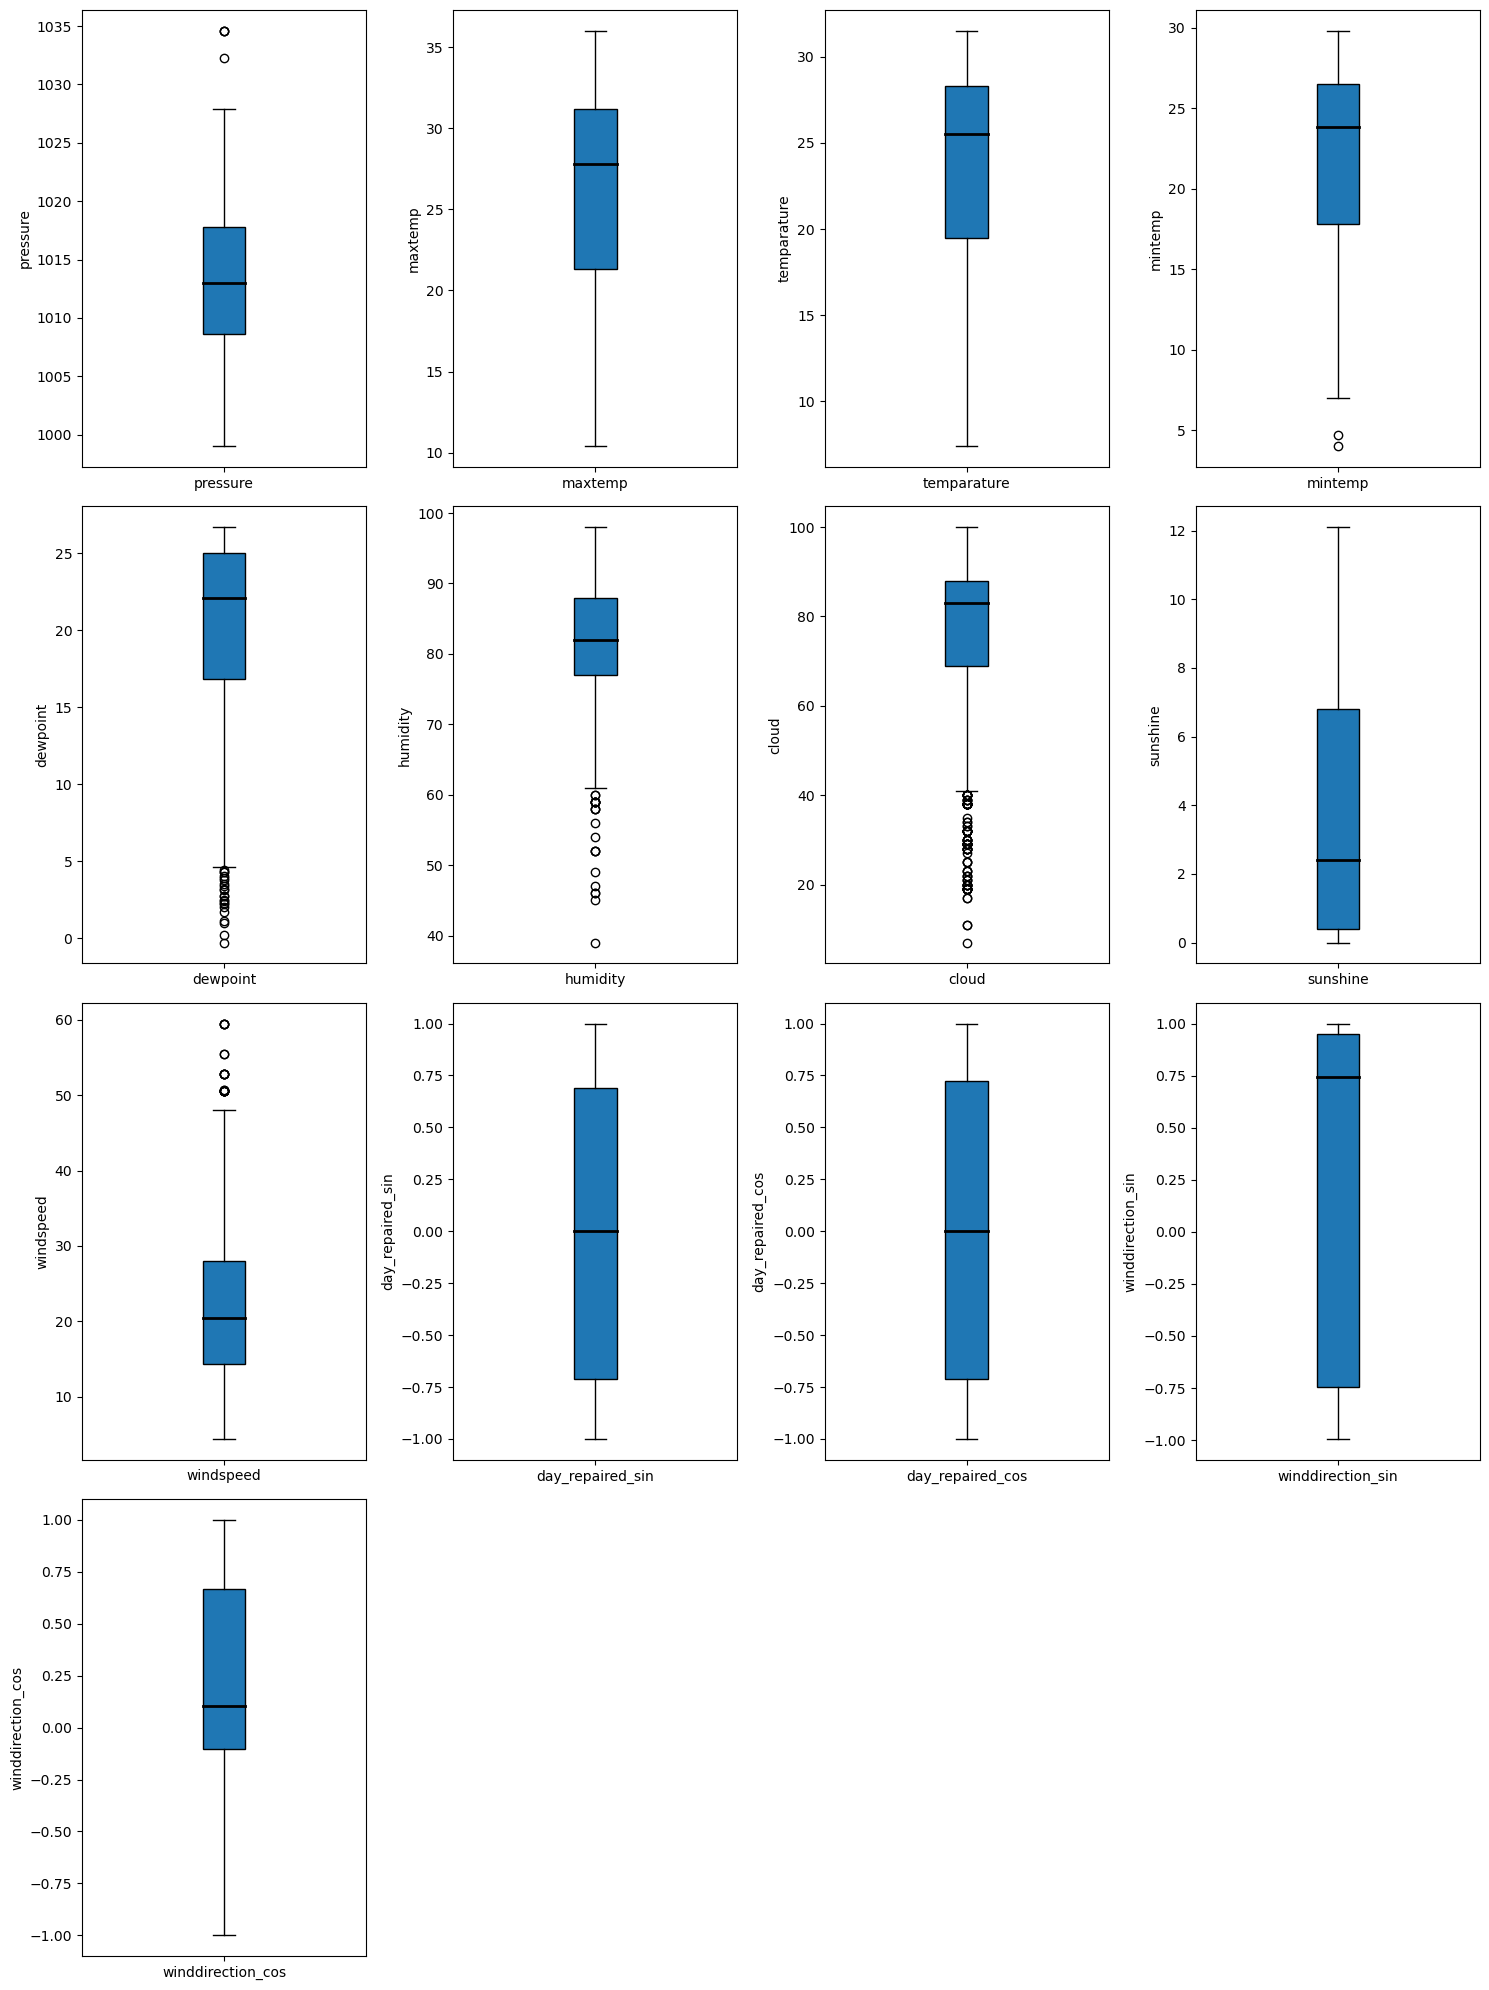

In [83]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(15, 20))
axes = axes.flatten() 

for idx, col in enumerate(columns):
    ax = axes[idx]
    bp = ax.boxplot(X_train[col].dropna(), patch_artist=True, labels=[col],
                    medianprops=dict(color='black', linewidth=2))

    for patch in bp['boxes']:
        patch.set_facecolor('#1f77b4')

    ax.set_ylabel(col)

for idx in range(len(columns), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

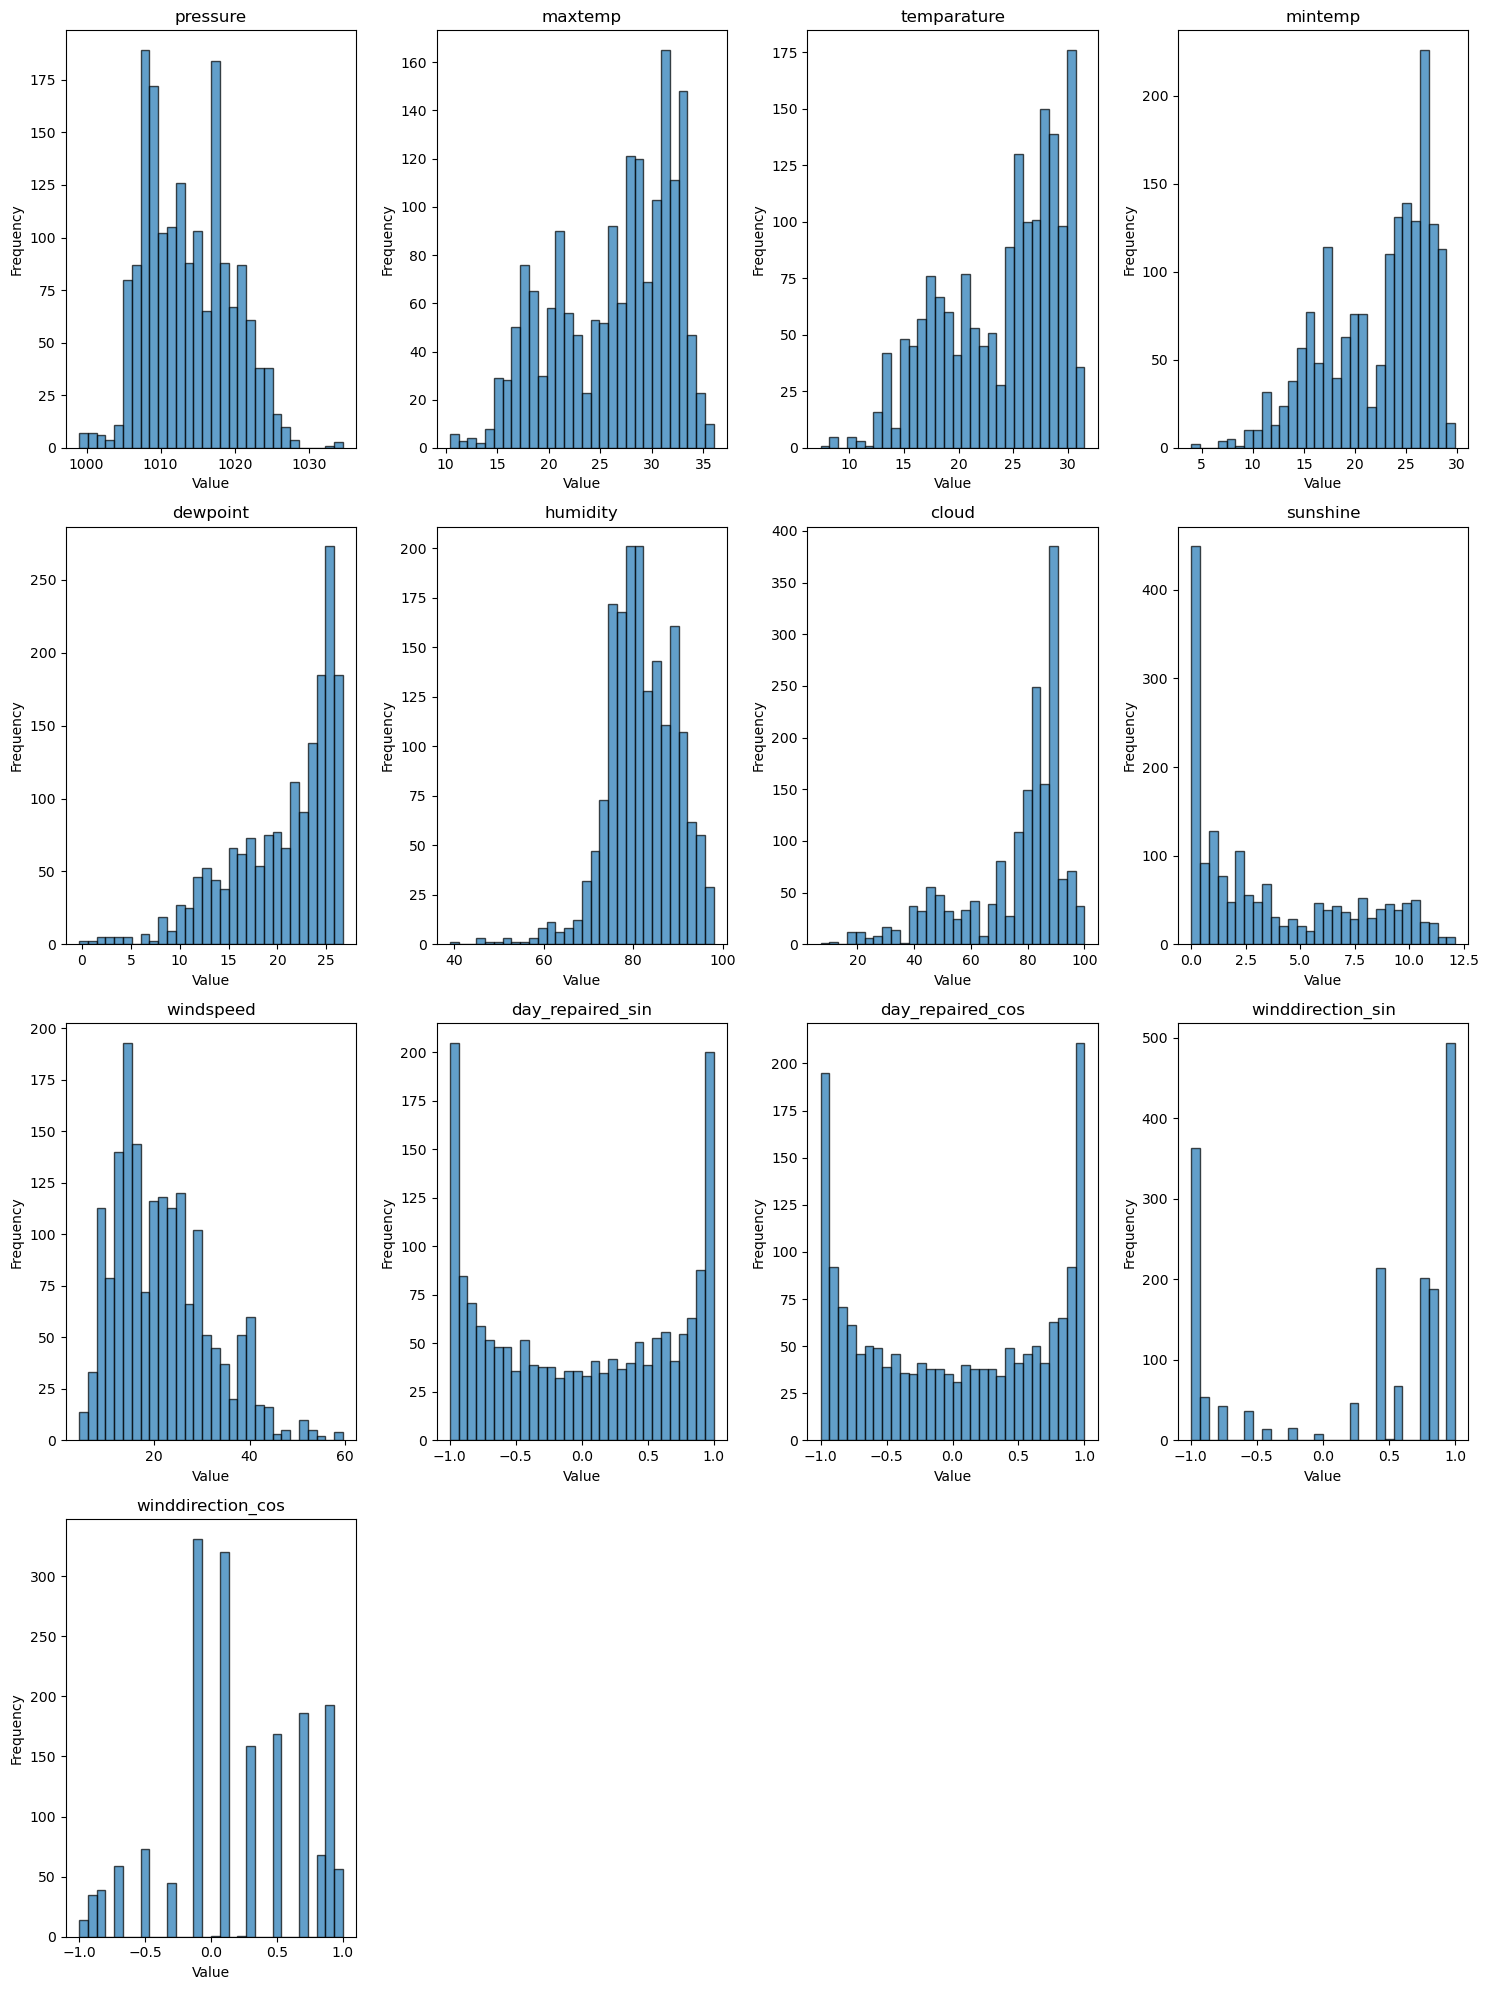

In [85]:
n_rows, n_cols = 4, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))
axes = axes.flatten()

for idx, col in enumerate(columns):
    ax = axes[idx]
    ax.hist(X_train[col].dropna(), bins=30, color='#1f77b4', edgecolor='black', alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

for idx in range(len(columns), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

In [108]:
# Method 1: IQR ()
columns_to_check = {
    'humidity': 3.0,
    'cloud': 3.0,
    'windspeed': 2.0,
    'mintemp': 1.5
}

train_filtered = df_train.copy()

for col, iqr_multiplier in columns_to_check.items():
    Q1 = train_filtered[col].quantile(0.25)
    Q3 = train_filtered[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - iqr_multiplier * IQR
    upper_bound = Q3 + iqr_multiplier * IQR
    
    train_filtered = train_filtered[(train_filtered[col] >= lower_bound) & (train_filtered[col] <= upper_bound)]

# Method 2: Z-score (for variables with a normal distribution)
from scipy import stats

z_scores = np.abs(stats.zscore(train_filtered[['pressure', 'temparature', 'maxtemp']]))
mask = (z_scores < 3).all(axis=1)
train_filtered = train_filtered[mask].reset_index(drop=True)

X_train_filtered = train_filtered.drop('rainfall', axis=1)
Y_train_filtered = train_filtered['rainfall']

# Method 3: DBSCAN (for cyclical data)
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.4, min_samples=3)
labels = dbscan.fit_predict(X_train_filtered[['winddirection_sin', 'winddirection_cos', 'day_repaired_sin', 'day_repaired_cos']])
mask = labels != -1
X_train_filtered = X_train_filtered[mask].reset_index(drop=True)
Y_train_filtered = Y_train_filtered[mask].reset_index(drop=True)
train_filtered = pd.concat([X_train_filtered, Y_train_filtered], axis=1)

print(len(df_train))
print(len(train_filtered))

1749
1725


### Isolation Forest (for all data)

In [109]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.01, random_state=42)
predictions = iso_forest.fit_predict(X_train)
mask = predictions != -1 
X_cleaned = X_train[mask].reset_index(drop=True)
y_cleaned = Y_train[mask].reset_index(drop=True)

print(f"Length of the original data: {len(X_train)}")
print(f"After Isolation Forest: {len(X_cleaned)}")

c:\Users\Ola\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Length of the original data: 1749
After Isolation Forest: 1731
